In [37]:
# Please execute/shift-return this cell everytime you run the notebook.  Don't edit it. 
from notebook import * 

# Q1 (20 points, 10 for each sub question)

1.  Assume that your computer can perform 4 double-precision floating-point
operations per clock cycle when the operands are stored in registers. Additionally,
accessing an operand from memory incurs a delay of 100 cycles for reading or
writing. The clock frequency of your computer is 2 GHz.

- How long will it take for your computer to complete the algorithms dgemm0 and
dgemm1 respectively, for n=1000? Please provide the answer in seconds.

- How much time is spent on reading/writing operands from/to memory for
dgemm0 and dgemm1 respectively, when n=1000? Please provide the answer in
seconds.

## Hint:

1. If less than 4 floating-point operations are executed continuously, they also
takes 1 cycle.
2. floating points are usually stored in the memory. When they are read, they
are loaded into registers. When they are written, they are stored into
memory.
3. We assume integer calculations take no time; no parallelism is considered in
this case.

## Q1 (a answer 

inner loop of dgemm0 takes 3 read from memory and 1 write to the memory, suppose C[i*n+j] += A[i*n+k] * B[k*n+j] first calculate i*n+j, i*n+k, k*n+j, since we assume integer calculations takes no time, these instructions time is ignored , then load A[i*n+k] and  B[k*n+j], C[i*n+j] into register, takes 3*100 cycles. then do a float multiply A[i*n+k] * B[k*n+j], then do a float add of C[i*n+j]+A[i*n+k] * B[k*n+j], since we assume we take 4 float operations in 1 cycle, it take 1 cycles. then we need to store the result back into memory, which take 100 cycles.

so the operation takes $ 300+1+100=401 $ cycles.

$$ 1000^3 * 401 / (2*10^9) =200.5 $$

###  it take for my computer to complete the algorithms for dgemm0 of  200.5 seconds

the memory operations takes $$ 1000^3 * 400 / (2*10^9) = 200.0 $$

### 200.0 seconds is spent on reading/writing operands from/to memory for dgemm0

second  loop j  of dgemm1 first load C[i*n+j] into register, which takes 100cycles.
then third loop k takes 2 read from memory and 1 write to the memory,
for  r += A[i*n+k] * B[k*n+j] first calculate  i*n+k, k*n+j, since we assume integer calculations takes no time, these instructions time is ignored , then load A[i*n+k] and  B[k*n+j] into register, takes 2*100 cycles. then do a float multiply A[i*n+k] * B[k*n+j], then do a float add of r+A[i*n+k] * B[k*n+j], since we assume we take 4 float operations in 1 cycle, it take 1 cycles. then we need to store the result back into register, which take 1 cycle.
then we goes into second loop j, We need to store the register value back to C[i*n+j] in the memory, which takes 100cycles.

for loop j, it takes $ n*n*(100+100)  = 1000*1000*(200) = 200000000 $ cycles.

for loop k, it takes $ n*n*n*(2*100+1+1) = 1000*1000*1000*(202)= 202000000000 $ cycles.

$$ (200000000+202000000000) / (2*10^9) =101.1 $$

### it take for my computer to complete the algorithms for dgemm1 of   101.1 seconds

the memory operations takes $$ (1000^3 * 200 + 1000^2*200) / (2*10^9) = 100.1 $$

### 100.1 seconds is spent on reading/writing operands from/to memory for dgemm1


In [4]:
compare([do_render_code("dgemm0.c", show="dgemm0"),
        do_render_code("dgemm1.c", show="dgemm1")])

In [5]:
!python bench1.py > bench1.csv

In [6]:
display_mono(render_csv("bench1.csv"))

,index,func,size,padding,time,correctness
0,0,dgemm0,64,1,0.000993s,1
1,1,dgemm1,64,1,0.000648s,1
2,2,dgemm0,128,1,0.008805s,1
3,3,dgemm1,128,1,0.005495s,1
4,4,dgemm0,256,1,0.119891s,1
5,5,dgemm1,256,1,0.048847s,1
6,6,dgemm0,512,1,1.165579s,1
7,7,dgemm1,512,1,0.765333s,1
8,8,dgemm0,1024,1,9.147360s,1
9,9,dgemm1,1024,1,5.879810s,1


##  Q1 (b answer 

### Verify the correctness of your implementation and report the time spent in the triple loop for each algorithm.

the running time is showing above, correctness column is whether the program is correct, if it is correct, the value is 1

### Calculate the performance of each algorithm in Gflops. Performance is typically measured as the number of floating-point operations executed per second. A performance of 1 Gflops corresponds to 10^9 floating-point operations per second.

for dgemm0 and dgemm1, each time a loop execution does 2 floating point operations.so

$$Gflops = \frac{n^3*2}{time} $$

please scoll down to see the results.

In [15]:
import pandas as pd
import numpy as np
file_path = 'bench1.csv'
data = pd.read_csv(file_path)
data.columns = data.columns.str.strip()
data.drop('padding', axis=1, inplace=True)
data.drop('correctness', axis=1, inplace=True)
data['time'] = data['time'].str.replace('s', '').astype(float)
data['Gflops'] = (data['size'] ** 3 * 2) / data['time']

,func,size,time,Gflops
0,dgemm0,64,0.000993,5.279839e+08
1,dgemm1,64,0.000648,8.090864e+08
2,dgemm0,128,0.008805,4.763548e+08
3,dgemm1,128,0.005495,7.632946e+08
4,dgemm0,256,0.119891,2.798745e+08
5,dgemm1,256,0.048847,6.869292e+08
6,dgemm0,512,1.165579,2.303022e+08
7,dgemm1,512,0.765333,3.507433e+08
8,dgemm0,1024,9.147360,2.347654e+08
9,dgemm1,1024,5.879810,3.652301e+08


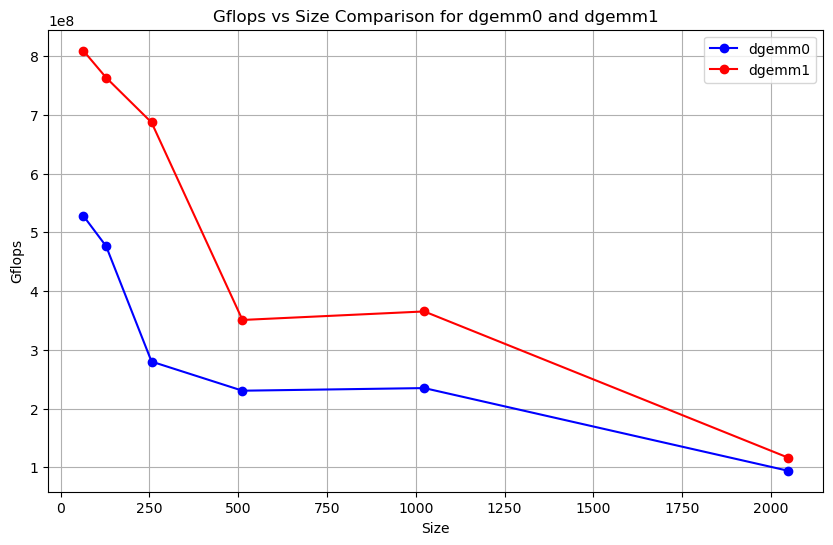

In [17]:
dgemm0_data = data[data['func'] == 'dgemm0']
dgemm1_data = data[data['func'] == 'dgemm1']

plt.figure(figsize=(10, 6))
plt.plot(dgemm0_data['size'], dgemm0_data['Gflops'], marker='o', linestyle='-', color='b', label='dgemm0')
plt.plot(dgemm1_data['size'], dgemm1_data['Gflops'], marker='o', linestyle='-', color='r', label='dgemm1')

plt.xlabel('Size')
plt.ylabel('Gflops')
plt.title('Gflops vs Size Comparison for dgemm0 and dgemm1')
plt.legend()
plt.grid(True)

display(data)
plt.show()

from the chart, We can see as matrix grows larger and larger, both dgemm0 and dgemm1 slows down, I think that's because cached data is populated out.

# Q2 (20 points)

Implement dgemm2 using 12 registers as outlined on Page 10 of optimizing-
sequential-programs.pptx. (shown in the figure below)
    
- Test dgemm2 on hpc-001 with n=64, 128, 256, 512, 1024, 2048.
-  Report the execution time and calculate the performance of your code in Gflops.

### let's analysis how many float point operations in dgemm2

in the loop k, c00 += a00*b00 + a01*b10, a00*b00 and a01*b10 are 2 multiplies, a00*b00 + a01*b10 is 1 addition,
c00 = c00 + a00*b00 + a01*b10 is another 1 addition, so there are 4 float point operations in one loop iteration.

the loop will run $ (n/2)^3 $ times, so total float ops is $ (n/2)^3* 4 $

In [38]:
render_code("dgemm2.c", show="dgemm2")

// dgemm2.c:1-28 (28 lines)
void dgemm2(double *C,double *A,double *B,int n)
{
    int i,j,k;
    for(int i=0;i<n;i+=2){
        for(int j=0;j<n;j+=2){
            register double c00,c01,c10,c11;
            register int t1,t2;
            t1 = i*n+j;
            t2 = t1+n;//t2 = (i+1)*n+j;
            c00=C[t1];c01=C[t1+1];
            c10=C[t2];c11=C[t2+1];
            for(int k=0;k<n;k+=2){
                register int ta = i*n+k; register int tta = ta+n; register int tb = k*n+j; register int ttb = tb+n;
                register double a00 = A[ta]; register double a01 = A[ta+1]; register double a10 = A[tta]; register double a11 = A[tta+1];
                register double b00 = B[tb]; register double b01 = B[tb+1]; register double b10 = B[ttb]; register double b11 = B[ttb+1];
                c00 += a00*b00 + a01*b10;
                c01 += a00*b01 + a01*b11;
                c10 += a10*b00 + a11*b10;
                c11 += a10*b01 + a11*b11;
            }
            C[t1]=c00;
            C[t1+1]=c01;
            C[t2]=c10;
            C[t2+1]=c11;
        }
    }
     
}

### below is the correctness and running time of dgemm2

In [32]:
!python bench2.py > bench2.csv
display_mono(render_csv("bench2.csv"))

,index,func,size,padding,time,correctness
0,0,dgemm2,64,1,0.000245s,1
1,1,dgemm2,128,1,0.002010s,1
2,2,dgemm2,256,1,0.017457s,1
3,3,dgemm2,512,1,0.232088s,1
4,4,dgemm2,1024,1,1.743581s,1
5,5,dgemm2,2048,1,39.610940s,1


### below is the GFLOPS calculated and a chart comparing with dgemm0 dgemm1

,func,size,time,Gflops
0,dgemm2,64,0.000245,5.349878e+08
1,dgemm2,128,0.002010,5.216796e+08
2,dgemm2,256,0.017457,4.805298e+08
3,dgemm2,512,0.232088,2.891527e+08
4,dgemm2,1024,1.743581,3.079128e+08
5,dgemm2,2048,39.610940,1.084288e+08


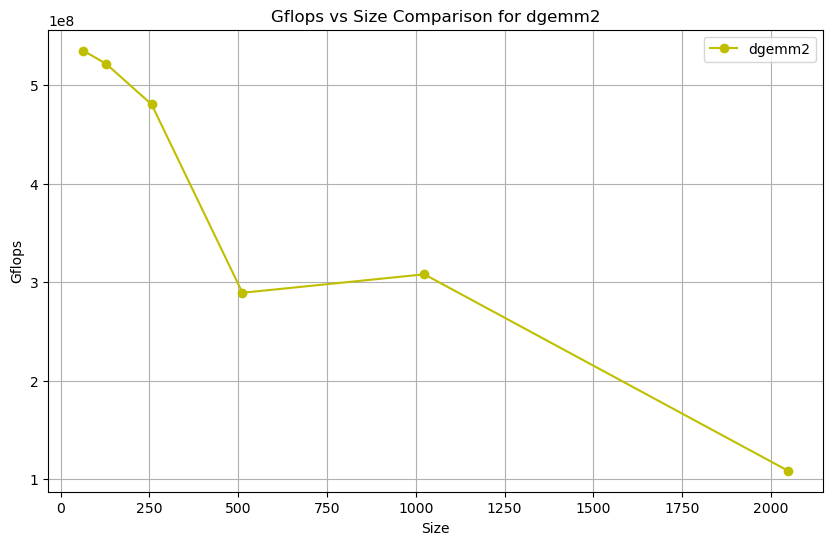

In [40]:
import pandas as pd
import numpy as np
def cleanning(df):
    df.columns = df.columns.str.strip()
    df = df.drop('padding', axis=1)
    df = df.drop('correctness', axis=1)
    df['time'] = df['time'].str.replace('s', '').astype(float)
    return df

data2 = cleanning(pd.read_csv('bench2.csv'))
data2['Gflops'] = ( (data2['size']/2) ** 3 * 4) / data2['time']
dgemm2_data = data2
plt.figure(figsize=(10, 6))
plt.plot(dgemm2_data['size'], dgemm2_data['Gflops'], marker='o', linestyle='-', color='y', label='dgemm2')
plt.xlabel('Size')
plt.ylabel('Gflops')
plt.title('Gflops vs Size Comparison for dgemm2')
plt.legend()
plt.grid(True)
display(data2)
plt.show()